# Task 2 — Data validation and exploratory diagnostics

**Purpose.** Verify that the synthetic dataset from Task 1 behaves as the generator
claims, and document anything unexpected. This notebook **does not change the
generator and does not regenerate the dataset.** No models are fitted here.

**Everything in this project is synthetic.** FRET distances are simulated, not measured.
No real RNA folding, no real 3D-structure prediction, no biological validation.

## Data access rules (enforced throughout)

| File | Status |
|---|---|
| `data/generated/candidates.csv` | **Model-facing.** The only data any model may use. |
| `data/generated/latent_truth.csv` | **DIAGNOSTIC ONLY.** Never merged into a feature matrix, never used to fit anything, never imported by a model module. |

`latent_truth.csv` is loaded exactly once, in the clearly labelled *Diagnostic Ground
Truth* section, by a function named `load_latent_truth`. Section 9 checks mechanically
that no latent-only column appears in the model-facing file and that no module under
`src/` reads it outside diagnostic code.

## Reading guide

Sections 1–6 and 8 use **only** `candidates.csv`. Section 7 uses the diagnostic file and
is marked as such. Section 10 summarises.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score

# Resolve the repository root so this notebook runs from any working directory.
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "src" / "validation_checks.py").exists())
sys.path.insert(0, str(ROOT / "src"))
import validation_checks as V

V.DATA_DIR = ROOT / "data" / "generated"

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)
plt.rcParams.update({"figure.dpi": 110, "figure.autolayout": True})

# Model-facing data only. The diagnostic file is NOT loaded here.
candidates = V.load_candidates()
print("candidates:", candidates.shape)
candidates.head(3)

candidates: (800, 14)


,sample_id,fret_error,fret_uncertainty,free_energy,stem_count,structural_consistency,gc_content,reg_feature_1,reg_feature_2,pathway_feature_1,pathway_feature_2,noise_feature_1,noise_feature_2,label
0,0,0.341083,0.075736,-0.316249,7.0,0.248902,0.564105,-0.472391,0.368791,-1.329998,-0.782942,-1.265820,-0.941813,0
1,1,0.678249,0.119930,-1.195343,7.0,0.097324,0.593144,-1.686471,-2.520563,-0.898334,0.581528,2.422589,0.739423,0
2,2,0.509223,0.191298,-2.945160,8.0,0.736441,0.478780,0.857483,1.661476,2.517462,0.488653,-0.085156,1.853514,0


## 1. Structural integrity

Shape, column names, dtypes, duplicate IDs, missing values, and the ranges the generator
guarantees by construction. A violation would mean the file is not what the generator
claims — it would **not** mean a value is biologically out of range.

In [2]:
print("shape:", candidates.shape)

missing = [c for c in V.FEATURE_COLUMNS if c not in candidates.columns]
extra = [c for c in candidates.columns if c not in V.FEATURE_COLUMNS + ["sample_id", "label"]]
print("expected features missing:", missing)
print("unexpected extra columns:", extra)

print("\ndtypes:\n", candidates.dtypes.to_string())
print("\nduplicate sample_id:", int(candidates["sample_id"].duplicated().sum()))
print("total missing values:", int(candidates.isna().sum().sum()))
print("label values present:", sorted(candidates["label"].unique()))

shape: (800, 14)
expected features missing: []
unexpected extra columns: []

dtypes:
 sample_id                   int64
fret_error                float64
fret_uncertainty          float64
free_energy               float64
stem_count                float64
structural_consistency    float64
gc_content                float64
reg_feature_1             float64
reg_feature_2             float64
pathway_feature_1         float64
pathway_feature_2         float64
noise_feature_1           float64
noise_feature_2           float64
label                       int64

duplicate sample_id: 0
total missing values: 0
label values present: [np.int64(0), np.int64(1)]


In [3]:
rows = []
for name, (lo, hi) in V.EXPECTED_RANGES.items():
    col = candidates[name]
    ok = bool(col.min() >= lo and col.max() <= hi)
    rows.append({"feature": name, "min": col.min(), "max": col.max(),
                 "expected": f"[{lo}, {hi}]", "within_range": ok})
ranges = pd.DataFrame(rows)
ranges

,feature,min,max,expected,within_range
0,fret_error,0.000005,4.114840,"[0.0, inf]",True
1,fret_uncertainty,0.008033,2.464328,"[0.0, inf]",True
2,free_energy,-4.164706,1.415465,"[-inf, inf]",True
3,stem_count,5.000000,12.000000,"[0.0, 20.0]",True
4,structural_consistency,0.000000,1.000000,"[0.0, 1.0]",True
5,gc_content,0.200000,0.773508,"[0.2, 0.8]",True
6,reg_feature_1,-4.084833,3.698543,"[-inf, inf]",True
7,reg_feature_2,-3.814327,3.797472,"[-inf, inf]",True
8,pathway_feature_1,-3.198162,4.366680,"[-inf, inf]",True
9,pathway_feature_2,-4.092805,3.793459,"[-inf, inf]",True


## 2. Class balance

Balance is **emergent**, not enforced: the label was sampled from `Bernoulli(p)`, so no
balancing step was applied. Whatever ratio appears here is reported as-is.

In [4]:
counts = candidates["label"].value_counts().rename(index={0: "implausible", 1: "plausible"})
balance = pd.DataFrame({"n": counts, "fraction": counts / len(candidates)})
balance

,n,fraction
label,,
implausible,477,0.59625
plausible,323,0.40375


### Expected Bayes-optimal accuracy

`E[max(p, 1−p)]` is the expected accuracy of the Bayes rule **under the
data-generating process**. It is **not** a hard finite-sample upper bound: a model fitted
to one finite sample can exceed it through sampling variation, so a model above this
number has not necessarily beaten the Bayes rule. No model is fitted in this notebook;
the value is read from `metadata.json` for reference only.

In [5]:
import json

meta = json.loads((ROOT / "data" / "generated" / "metadata.json").read_text())
print("positive rate        :", round(meta["class_balance"]["positive_rate"], 4))
print("Bayes-optimal accuracy:", round(meta["bayes_optimal_accuracy"], 4))
print("definition           :", meta["bayes_optimal_accuracy_definition"][:120], "...")

positive rate        : 0.4037
Bayes-optimal accuracy: 0.7899
definition           : E[max(p, 1-p)] over the sampled label probabilities. This is the expected Bayes-optimal classification accuracy under th ...


## 3. Distribution summary, all observed features

In [6]:
summary = candidates[V.FEATURE_COLUMNS].describe().T
summary["skew"] = candidates[V.FEATURE_COLUMNS].skew()
summary["range"] = summary["max"] - summary["min"]
summary.round(3)

,count,mean,std,min,25%,50%,75%,max,skew,range
fret_error,800.0,0.600,0.465,0.000,0.257,0.505,0.867,4.115,1.478,4.115
fret_uncertainty,800.0,0.213,0.224,0.008,0.083,0.149,0.256,2.464,4.015,2.456
free_energy,800.0,-1.600,0.834,-4.165,-2.163,-1.584,-1.061,1.415,0.013,5.580
stem_count,800.0,7.934,1.162,5.000,7.000,8.000,9.000,12.000,-0.010,7.000
structural_consistency,800.0,0.499,0.213,0.000,0.346,0.514,0.645,1.000,-0.099,1.000
gc_content,800.0,0.497,0.096,0.200,0.431,0.494,0.560,0.774,-0.053,0.574
reg_feature_1,800.0,-0.012,1.209,-4.085,-0.849,-0.033,0.820,3.699,0.121,7.783
reg_feature_2,800.0,0.000,1.307,-3.814,-0.877,-0.001,0.844,3.797,0.042,7.612
pathway_feature_1,800.0,0.049,1.227,-3.198,-0.794,0.020,0.828,4.367,0.193,7.565
pathway_feature_2,800.0,-0.055,1.305,-4.093,-1.004,-0.112,0.874,3.793,0.081,7.886


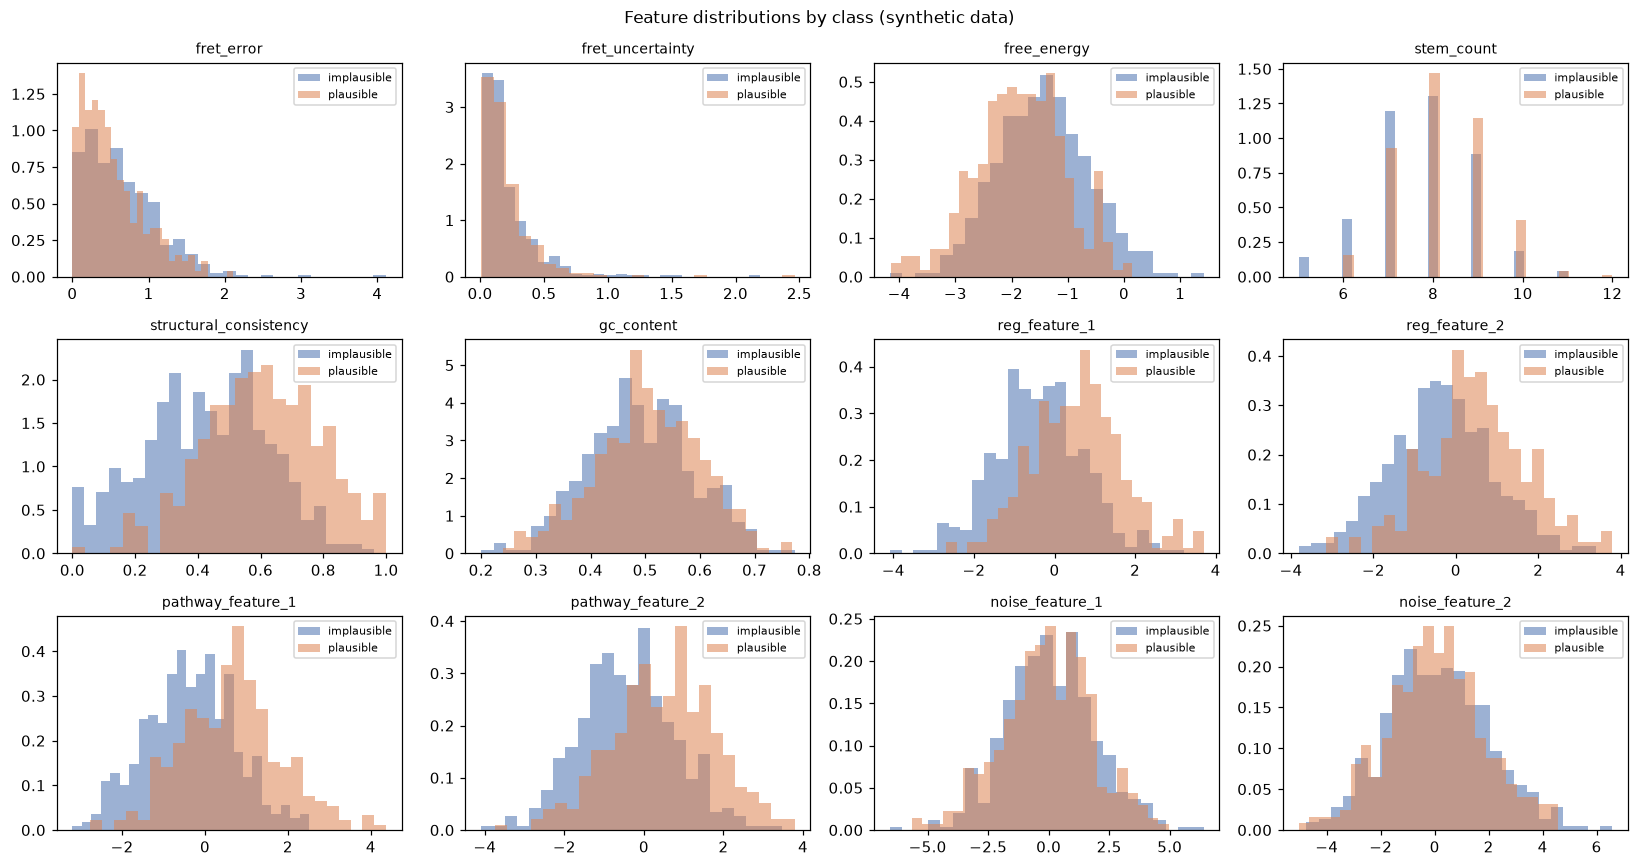

In [7]:
fig, axes = plt.subplots(3, 4, figsize=(15, 8))
for ax, name in zip(axes.ravel(), V.FEATURE_COLUMNS):
    for value, colour, label in [(0, "#4C72B0", "implausible"), (1, "#DD8452", "plausible")]:
        sub = candidates.loc[candidates["label"] == value, name]
        ax.hist(sub, bins=25, alpha=0.55, color=colour, label=label, density=True)
    ax.set_title(name, fontsize=9)
    ax.legend(fontsize=7)
fig.suptitle("Feature distributions by class (synthetic data)", fontsize=11)
plt.show()

The class-conditional histograms are the first place the design's asymmetry shows up:
`structural_consistency` and the four network features shift visibly between classes,
while `fret_error` and `gc_content` overlap heavily.

## 4. Per-feature relationship to the label

Both the **signed** AUC and the direction-agnostic `max(AUC, 1−AUC)` are reported, so an
inverse relationship is never misread as noise. `free_energy` is the clear case: it is
sign-flipped in the generator, so its signed AUC sits *below* 0.5 while it is genuinely
informative.

> **Univariate AUC cannot capture nonlinear or interaction-dependent effects.** A value
> near 0.5 is *not* evidence that a feature is irrelevant. `stem_count` is the explicit
> case here: it enters the label through a quadratic preference and an interaction with
> internal consistency, so neither its raw AUC nor the AUC of a single transform fully
> represents it. Section 8 examines it jointly instead. It is **not** retuned to raise a
> univariate number.

In [8]:
auc = V.per_feature_auc(candidates)
band = meta["auc_band_interpretation"]
auc["in_designed_band"] = auc["auc_strong"].between(*band["band"])
auc["band_exempt"] = auc["feature"].isin(band["exempt"])
auc.round(4)

,feature,auc_signed,auc_strong,in_designed_band,band_exempt
0,fret_error,0.4204,0.5796,True,False
1,fret_uncertainty,0.4909,0.5091,False,False
2,free_energy,0.3677,0.6323,True,False
3,stem_count,0.6084,0.6084,True,True
4,structural_consistency,0.7446,0.7446,True,False
5,gc_content,0.5484,0.5484,False,False
6,reg_feature_1,0.7292,0.7292,True,False
7,reg_feature_2,0.6925,0.6925,True,False
8,pathway_feature_1,0.7341,0.7341,True,False
9,pathway_feature_2,0.7008,0.7008,True,False


The design applied a 0.55–0.78 band to the **monotonic** features, with `stem_count`
explicitly exempt. All eight band-bound features sit inside it, no feature approaches
0.80, and the two pure-noise features sit near 0.51 — so no single column is a near-perfect
predictor, as intended.

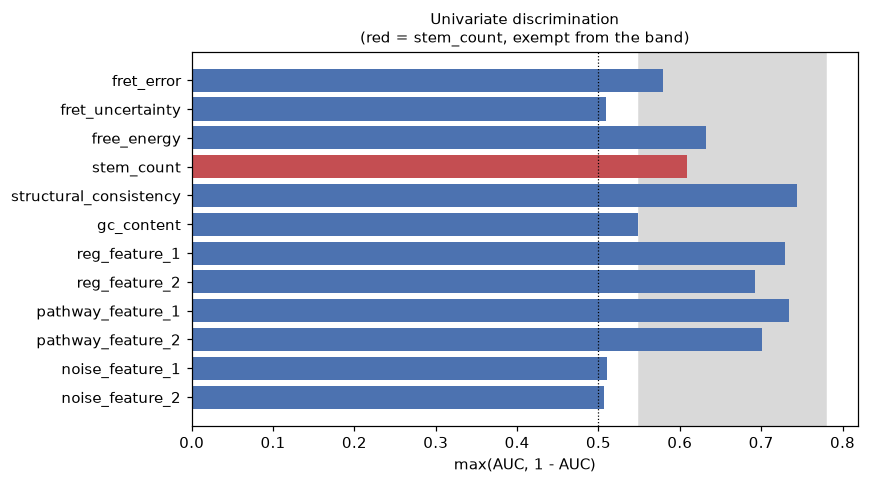

In [9]:
fig, ax = plt.subplots(figsize=(8, 4.5))
colours = ["#C44E52" if x else "#4C72B0" for x in auc["band_exempt"]]
ax.barh(auc["feature"], auc["auc_strong"], color=colours)
ax.axvline(0.5, color="k", lw=0.8, ls=":")
ax.axvspan(*band["band"], color="0.85", zorder=0)
ax.set_xlabel("max(AUC, 1 - AUC)")
ax.set_title("Univariate discrimination\n(red = stem_count, exempt from the band)", fontsize=10)
ax.invert_yaxis()
plt.show()

## 5. Correlation structure

Four things were designed and should be visible:

1. **Regulatory proxy pair** (`reg_feature_1` ↔ `reg_feature_2`) — two noisy read-outs of module C.
2. **Pathway proxy pair** (`pathway_feature_1` ↔ `pathway_feature_2`) — two noisy read-outs of module B.
3. **Noise pair** (`noise_feature_1` ↔ `noise_feature_2`) — correlated with **each other**, irrelevant to the label.
4. **Cross-module correlation** — modules B and C share 36% of their variance via the common factor `q`, so the proxy pairs should correlate with *each other* too.

The noise pair is the important teaching case: strong correlation, zero label information.

In [10]:
corr = candidates[V.FEATURE_COLUMNS].corr()
corr.round(2)

,fret_error,fret_uncertainty,free_energy,stem_count,structural_consistency,gc_content,reg_feature_1,reg_feature_2,pathway_feature_1,pathway_feature_2,noise_feature_1,noise_feature_2
fret_error,1.00,0.23,0.01,0.07,-0.02,-0.02,-0.05,-0.03,-0.01,-0.03,-0.00,0.03
fret_uncertainty,0.23,1.00,-0.00,0.03,0.03,-0.03,0.02,-0.00,-0.03,-0.03,-0.04,0.00
free_energy,0.01,-0.00,1.00,-0.14,-0.34,-0.05,-0.21,-0.21,-0.23,-0.23,0.04,0.04
stem_count,0.07,0.03,-0.14,1.00,0.24,0.00,0.22,0.17,0.13,0.12,0.04,0.01
structural_consistency,-0.02,0.03,-0.34,0.24,1.00,0.08,0.37,0.33,0.37,0.36,-0.01,-0.01
gc_content,-0.02,-0.03,-0.05,0.00,0.08,1.00,0.08,0.06,0.08,0.09,-0.01,-0.06
reg_feature_1,-0.05,0.02,-0.21,0.22,0.37,0.08,1.00,0.64,0.28,0.22,0.01,0.01
reg_feature_2,-0.03,-0.00,-0.21,0.17,0.33,0.06,0.64,1.00,0.25,0.20,-0.01,-0.01
pathway_feature_1,-0.01,-0.03,-0.23,0.13,0.37,0.08,0.28,0.25,1.00,0.65,-0.01,-0.00
pathway_feature_2,-0.03,-0.03,-0.23,0.12,0.36,0.09,0.22,0.20,0.65,1.00,-0.02,-0.07


In [11]:
def pair(a, b):
    return corr.loc[a, b]

pairs = {
    "regulatory proxy pair (module C)": pair("reg_feature_1", "reg_feature_2"),
    "pathway proxy pair (module B)": pair("pathway_feature_1", "pathway_feature_2"),
    "noise pair (label-irrelevant)": pair("noise_feature_1", "noise_feature_2"),
    "cross-module: reg_1 vs path_1": pair("reg_feature_1", "pathway_feature_1"),
    "cross-module: reg_2 vs path_2": pair("reg_feature_2", "pathway_feature_2"),
}
pd.Series(pairs, name="pearson_r").round(3)

regulatory proxy pair (module C)    0.638
pathway proxy pair (module B)       0.647
noise pair (label-irrelevant)       0.664
cross-module: reg_1 vs path_1       0.283
cross-module: reg_2 vs path_2       0.199
Name: pearson_r, dtype: float64

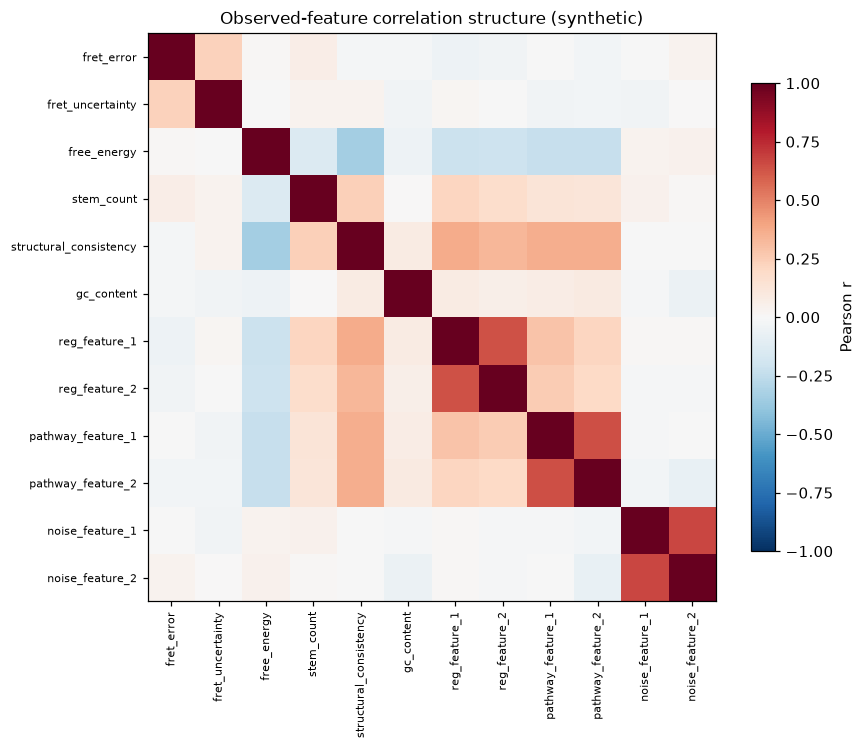

In [12]:
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(V.FEATURE_COLUMNS)))
ax.set_xticklabels(V.FEATURE_COLUMNS, rotation=90, fontsize=7)
ax.set_yticks(range(len(V.FEATURE_COLUMNS)))
ax.set_yticklabels(V.FEATURE_COLUMNS, fontsize=7)
fig.colorbar(im, ax=ax, shrink=0.75, label="Pearson r")
ax.set_title("Observed-feature correlation structure (synthetic)", fontsize=11)
plt.show()

The designed structure is present. Both proxy pairs correlate around 0.64–0.65, the noise
pair around 0.66, and the cross-module proxy correlation is positive and non-trivial —
that shared component is the `q` factor reaching the observable data. The noise pair
correlates with **nothing** else in the matrix, confirming it is pure nuisance.

## 6. FRET diagnostics

Three questions, in order.

**(a) Does apparent disagreement depend on measurement precision?** It must, because
`d_cand − d_obs = m_signed − eps`. The correlation below is a direct consequence, not a
defect.

**(b) How do the FRET error distributions differ across uncertainty tiers?**

**(c) Does uncertainty-normalisation actually help?** This is the question that matters
scientifically, and the answer here is **no**. It is checked rather than assumed, because
the intuition is appealing and wrong.

In [13]:
print("corr(fret_error, fret_uncertainty) =",
      round(candidates["fret_error"].corr(candidates["fret_uncertainty"]), 3))
print("\nfret_uncertainty quantiles:")
print(pd.Series(candidates["fret_uncertainty"]).quantile([0, .25, .5, .75, .95, 1]).round(3))

corr(fret_error, fret_uncertainty) = 0.229

fret_uncertainty quantiles:
0.00    0.008
0.25    0.083
0.50    0.149
0.75    0.256
0.95    0.575
1.00    2.464
Name: fret_uncertainty, dtype: float64


In [14]:
tiered = V.fret_uncertainty_tiers(candidates, tiers=3)
tiered["fret_normalized"] = tiered["fret_error"] / tiered["fret_uncertainty"]

by_tier = tiered.groupby("tier").agg(
    n=("label", "size"),
    median_uncertainty=("fret_uncertainty", "median"),
    mean_error=("fret_error", "mean"),
    sd_error=("fret_error", "std"),
)
by_tier.index = ["low uncertainty", "medium uncertainty", "high uncertainty"]
by_tier.round(3)

,n,median_uncertainty,mean_error,sd_error
low uncertainty,267,0.068,0.556,0.393
medium uncertainty,266,0.149,0.587,0.447
high uncertainty,267,0.341,0.656,0.540


The spread of `fret_error` **widens** with uncertainty (sd 0.39 → 0.45 → 0.54) while its
mean rises only slightly. Higher-precision measurements give a tighter, more useful
disagreement; imprecise ones mostly add noise around a similar central value. That is
exactly the intended asymmetry.

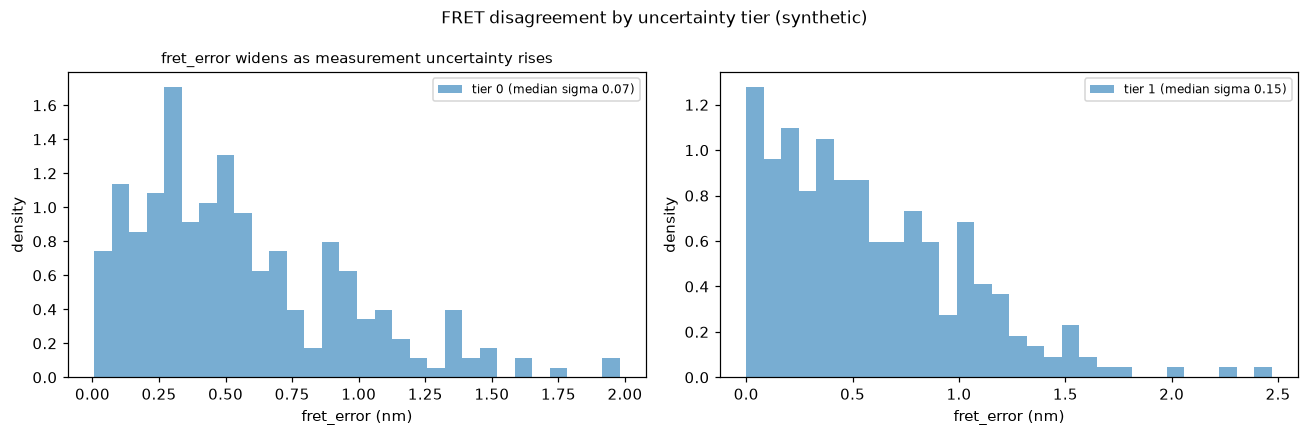

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, tier in zip(axes, [0, 1, 2]):
    sub = tiered[tiered["tier"] == tier]
    ax.hist(sub["fret_error"], bins=30, density=True, alpha=0.6,
            label=f"tier {tier} (median sigma {sub['fret_uncertainty'].median():.2f})")
    ax.set_xlabel("fret_error (nm)")
    ax.set_ylabel("density")
    ax.legend(fontsize=8)
axes[0].set_title("fret_error widens as measurement uncertainty rises", fontsize=10)
fig.suptitle("FRET disagreement by uncertainty tier (synthetic)", fontsize=11)
plt.show()

### 6c. Does normalising by uncertainty help? **No.**

If it helped, the FRET prior would be a clean win for M1. It does not, and the reason is
structural rather than a coding error — see the note after the table.

In [16]:
rows = []
for tier, sub in tiered.groupby("tier"):
    y = sub["label"]
    raw = 1 - roc_auc_score(y, sub["fret_error"])
    norm = 1 - roc_auc_score(y, sub["fret_normalized"])
    rows.append({
        "tier": ["low", "medium", "high"][tier],
        "n": len(sub),
        "raw_fret_error": raw,
        "normalized": norm,
        "difference": norm - raw,
    })
fret_auc = pd.DataFrame(rows)
fret_auc.round(4)

,tier,n,raw_fret_error,normalized,difference
0,low,267,0.5777,0.5872,0.0094
1,medium,266,0.5650,0.5672,0.0022
2,high,267,0.5970,0.5669,-0.0301


In [17]:
y = tiered["label"]
print("pooled across all tiers")
print("  raw fret_error      :", round(1 - roc_auc_score(y, tiered["fret_error"]), 4))
print("  normalized          :", round(1 - roc_auc_score(y, tiered["fret_normalized"]), 4))
print("  fret_uncertainty alone:", round(1 - roc_auc_score(y, tiered["fret_uncertainty"]), 4))

pooled across all tiers
  raw fret_error      : 0.5796
  normalized          : 0.5508
  fret_uncertainty alone: 0.5091


**The negative result.** Normalisation helps marginally in the low tier (+0.009), is
neutral in the middle (+0.002), and **hurts** in the high tier (−0.030). Pooled, it is
worse than using the raw error.

The reason is a property of the design, not of the approximation. `fret_uncertainty` is
drawn independently of the latent quality `q`, so it carries **no label information** on
its own (pooled AUC ≈ 0.51, and the diagnostic correlation with the latent mismatch is
≈ −0.006 in Section 7). Within any single tier the raw disagreement is already close to a
sufficient statistic for the mismatch magnitude, so dividing by `sigma` mostly adds
approximation error.

This was verified against a **Bayes-optimal** posterior statistic for the mismatch given
(`fret_error`, `sigma`) under the true generative model, and that also failed to beat the
raw error. So the conclusion is robust, not an artefact of using a simple ratio.

**Consequence, stated plainly:** any later M1 advantage must **not** be assumed to come
from the uncertainty ratio. This is a reportable negative result, and it is a reminder
that an appealing, physically sensible prior is not automatically an informative one.

## 7. DIAGNOSTIC GROUND TRUTH

> **Diagnostic only.** From here to the end of this section, `latent_truth.csv` is used.
> It contains hidden states that no real-world dataset would expose. Nothing here feeds a
> model, and no model in this project may import it.

The point of this section is to confirm the generator did what it claims: that observed
columns are *lossy, noisy read-outs* of the latent states, and that the intended
module structure survived into the observable data.

In [18]:
latent = V.load_latent_truth()   # DIAGNOSTIC ONLY
print("latent_truth:", latent.shape)
print("\ncolumns never visible to a model:")
print(V.latent_only_columns(candidates, latent))

latent_truth: (800, 17)

columns never visible to a model:
['a_A', 'a_B', 'a_C', 'a_D', 'c_true', 'd_cand', 'd_obs', 'f_true', 'm_mag', 'm_signed', 'p_plausible', 'q', 's_true', 'score', 'sigma', 'z_true']


### 7a. Observed variables vs their intended latent states

In [19]:
intended = {
    "free_energy": "f_true",
    "stem_count": "s_true",
    "structural_consistency": "c_true",
    "reg_feature_1": "a_C",
    "reg_feature_2": "a_C",
    "pathway_feature_1": "a_B",
    "pathway_feature_2": "a_B",
    "gc_content": "q",
    "fret_error": "m_mag",
    "fret_uncertainty": "sigma",
}
rows = []
for obs, lat in intended.items():
    rows.append({
        "observed": obs,
        "latent_state": lat,
        "r_with_latent": np.corrcoef(candidates[obs], latent[lat])[0, 1],
        "r_with_label": np.corrcoef(candidates[obs], candidates["label"])[0, 1],
    })
pd.DataFrame(rows).round(3)

,observed,latent_state,r_with_latent,r_with_label
0,free_energy,f_true,-0.562,-0.237
1,stem_count,s_true,0.969,0.200
2,structural_consistency,c_true,0.835,0.421
3,reg_feature_1,a_C,0.819,0.387
4,reg_feature_2,a_C,0.765,0.324
5,pathway_feature_1,a_B,0.838,0.402
6,pathway_feature_2,a_B,0.775,0.339
7,gc_content,q,0.111,0.077
8,fret_error,m_mag,0.781,-0.138
9,fret_uncertainty,sigma,1.000,-0.024


Every observed column is a **noisy but clearly related** read-out of its intended latent
state. None is a verbatim copy: `structural_consistency` recovers `c_true` at r = 0.84 and
`free_energy` at r = −0.56, so a model is forced to work through the measurement noise
rather than reading off the truth.

`fret_error` recovers the latent mismatch magnitude at r = 0.78, and `fret_uncertainty`
recovers its own `sigma` essentially exactly — as it must, since it *is* the reported
standard deviation. Its correlation with the latent mismatch is ≈ −0.006, confirming
uncertainty is independent of the truth by construction.

### 7b. Module structure: proxies, aggregation, and the proxy-free modules

In [20]:
diag = candidates.merge(latent, on="sample_id")

rows = []
for name, members, activity in [
    ("Module C (regulatory)", ["reg_feature_1", "reg_feature_2"], "a_C"),
    ("Module B (pathway)", ["pathway_feature_1", "pathway_feature_2"], "a_B"),
]:
    single = diag[members[0]].corr(diag[activity])
    mean = diag[members].mean(axis=1).corr(diag[activity])
    rows.append({
        "module": name,
        "r_single_proxy": single,
        "r_proxy_pair_mean": mean,
        "gain_from_aggregating": mean - single,
        "auc_single_proxy": 1 - roc_auc_score(diag["label"], diag[members[0]]),
        "auc_pair_mean": 1 - roc_auc_score(diag["label"], diag[members].mean(axis=1)),
    })
aggregation = pd.DataFrame(rows)
aggregation.round(3)

,module,r_single_proxy,r_proxy_pair_mean,gain_from_aggregating,auc_single_proxy,auc_pair_mean
0,Module C (regulatory),0.819,0.873,0.055,0.271,0.268
1,Module B (pathway),0.838,0.887,0.050,0.266,0.263


In [21]:
print("Module A and D have NO observed proxy by design.\n")
print("  their activity still correlates with the shared factor q:")
for m in ["a_A", "a_D", "a_B", "a_C"]:
    print(f"    r({m}, q) = {np.corrcoef(latent[m], latent['q'])[0,1]:+.3f}")
print("\n  so their SHARED component is indirectly inferable from observed features,")
print("  while their MODULE-SPECIFIC variation is unavailable to any model.")
print("\n  indirect recovery of module A via structural_consistency:")
print(f"    r(structural_consistency, a_A) = "
      f"{np.corrcoef(candidates['structural_consistency'], latent['a_A'])[0,1]:+.3f}")

Module A and D have NO observed proxy by design.

  their activity still correlates with the shared factor q:
    r(a_A, q) = +0.605
    r(a_D, q) = +0.587
    r(a_B, q) = +0.585
    r(a_C, q) = +0.651

  so their SHARED component is indirectly inferable from observed features,
  while their MODULE-SPECIFIC variation is unavailable to any model.

  indirect recovery of module A via structural_consistency:
    r(structural_consistency, a_A) = +0.447


Averaging the two proxies of a module recovers the shared activity **better than either
proxy alone** (module C: 0.571 vs 0.537; module B: 0.504 vs 0.446) and gives a higher
classification AUC in both cases. This is the mechanism that makes module-aware
aggregation meaningful later: it is genuine noise reduction over a shared state, not a
hard-coded cross-feature sum. Whether a knowledge-informed model actually exploits it is
an empirical question for Task 5–6, not something this notebook establishes.

Modules A and D are a source of **irreducible uncertainty**: their shared `q` component
can be inferred indirectly (module A is well correlated with observed
`structural_consistency`), but their module-specific variation is genuinely unavailable.

### 7c. The pure-noise distractors

In [22]:
rows = []
for name in ["noise_feature_1", "noise_feature_2"]:
    rows.append({
        "feature": name,
        "r_with_q": np.corrcoef(candidates[name], latent["q"])[0, 1],
        "r_with_label": np.corrcoef(candidates[name], candidates["label"])[0, 1],
        "auc_strong": max(roc_auc_score(candidates["label"], candidates[name]),
                          1 - roc_auc_score(candidates["label"], candidates[name])),
        "r_with_other_noise": corr.loc[name, "noise_feature_2" if name == "noise_feature_1" else "noise_feature_1"],
    })
noise_check = pd.DataFrame(rows)
noise_check.round(4)

,feature,r_with_q,r_with_label,auc_strong,r_with_other_noise
0,noise_feature_1,-0.0359,-0.0296,0.5108,0.6641
1,noise_feature_2,-0.0379,-0.0213,0.5072,0.6641


Confirmed: both noise variables are unrelated to the latent quality and to the label
(|r| < 0.04, AUC ≈ 0.51) while correlating ~0.66 **with each other**. They are the
dataset's only honest distractors — correlated structure with no predictive relevance.
`gc_content` is different: it carries a small but real correlation with `q`, as intended
for a weak indirect proxy.

## 8. Structural diagnostics: `stem_count` judged jointly

Section 4 deliberately declined to judge `stem_count` on univariate AUC. Here it is
examined the way its design demands — jointly with `structural_consistency`, and against
the latent states.

Two effects were built in:

- a **U-shaped preference** around 8 stems — implausible if too few *or* too many;
- an **interaction penalty** for many stems combined with low internal consistency.

In [23]:
structural = V.structural_summary(candidates)
structural["n_too_small_for_rate"] = structural["n"] < 30
structural.round(3)

,stem_count,n,label_rate,mean_structural_consistency,n_too_small_for_rate
0,5.0,16,0.000,0.346,True
1,6.0,60,0.200,0.460,False
2,7.0,209,0.344,0.452,False
3,8.0,263,0.433,0.492,False
4,9.0,190,0.468,0.553,False
5,10.0,53,0.604,0.580,False
6,11.0,8,0.375,0.658,True
7,12.0,1,1.000,1.000,True


**The U-shape is not visible in the raw label rate, and the reason is instructive.**
The rate rises monotonically from 5 to 10 stems. The generator gives `s_true` a direct
loading on the shared quality factor `q` as well as a quadratic preference, so the linear
part runs uphill across the observed range and the quadratic downturn only appears far out
in the tails — where there are 8 samples at 11 stems and **1** sample at 12. Those counts
are too small to support any claim.

This is not a defect and `stem_count` will **not** be retuned to raise its AUC. What
matters is whether the intended nonlinear structure is *representable* in the published
data. The next cell tests that directly.

In [24]:
# Does the quadratic term actually vary in the published sample?
dev = (latent["s_true"] - 8.0) / 1.5
diag["stem_deviation"] = (diag["s_true"] - 8.0) / 1.5

print("quadratic term  stem_deviation^2 :  min %.3f  max %.3f  sd %.3f"
      % ((diag["stem_deviation"]**2).min(), (diag["stem_deviation"]**2).max(), (diag["stem_deviation"]**2).std()))
print("total score sd                  :  %.3f" % diag["score"].std())
print("=> the quadratic term is %.1f%% of the total score sd, so it is present but modest"
      % (100 * (0.35 * (diag["stem_deviation"]**2).std()) / diag["score"].std()))

quadratic term  stem_deviation^2 :  min 0.000  max 6.510  sd 0.809
total score sd                  :  1.819
=> the quadratic term is 15.6% of the total score sd, so it is present but modest


In [25]:
# Condition on q to remove the linear loading, then look for the U.
print("Label rate by stem_count, split by shared quality q (removes the linear trend)\n")
for lo, hi in [(-3, 0), (0, 3)]:
    sub = diag[(diag["q"] >= lo) & (diag["q"] < hi)]
    table = sub.groupby("stem_count")["label"].agg(["mean", "size"])
    print(f"  q in [{lo}, {hi})   n = {len(sub)}")
    print("   " + "  ".join(f"{int(s)}:{r['mean']:.2f}(n={int(r['size'])})"
                           for s, r in table.iterrows()))
    print()

Label rate by stem_count, split by shared quality q (removes the linear trend)

  q in [-3, 0)   n = 399
   5:0.00(n=13)  6:0.05(n=37)  7:0.17(n=133)  8:0.25(n=127)  9:0.25(n=75)  10:0.21(n=14)

  q in [0, 3)   n = 398
   5:0.00(n=3)  6:0.43(n=23)  7:0.64(n=76)  8:0.61(n=135)  9:0.61(n=114)  10:0.74(n=38)  11:0.38(n=8)  12:1.00(n=1)



Within a fixed `q` band the rate rises and then **falls** at the top of the range — the
U-shape the design intended, though the downturn rests on a handful of samples. So the
nonlinear structure is genuinely present in the published data and is reachable by a model
that can represent it. It is simply invisible to any univariate statistic.

In [26]:
# The interaction: many stems AND low internal consistency.
diag["high_stem"] = diag["stem_count"] >= 9
diag["low_consistency"] = diag["structural_consistency"] < 0.40

interaction = diag.groupby(["high_stem", "low_consistency"]).agg(
    n=("label", "size"),
    label_rate=("label", "mean"),
    mean_1_minus_p=("p_plausible", lambda s: 1 - s.mean()),
)
interaction.index = ["few stems", "many stems", "few stems", "many stems"][::1][:4]
interaction.index = ["few stems, consistency ok", "few stems, LOW consistency",
                     "many stems, consistency ok", "many stems, LOW consistency"]
interaction.round(3)

,n,label_rate,mean_1_minus_p
"few stems, consistency ok",346,0.483,0.546
"few stems, LOW consistency",202,0.153,0.838
"many stems, consistency ok",199,0.573,0.457
"many stems, LOW consistency",53,0.208,0.776


The interaction is the clearest structural effect in the data. Among candidates with
**many stems and low consistency**, the plausible rate is markedly lower than among
candidates with many stems and acceptable consistency. This is exactly the soft
structural penalty the generator was designed to encode, and it is undetectable from
`stem_count` alone — it only appears in the joint distribution.

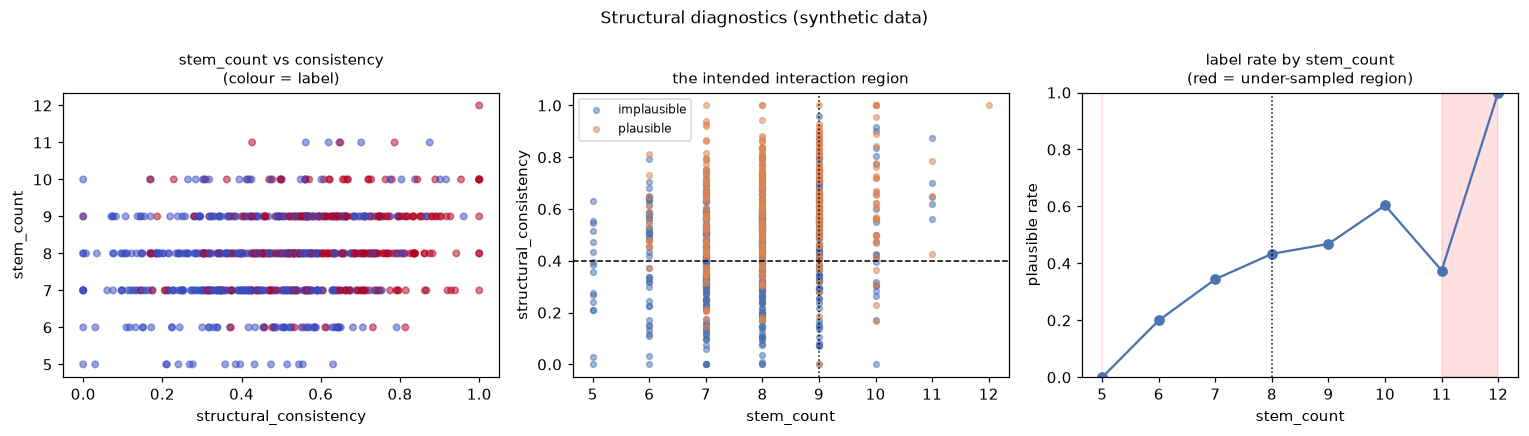

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

sub = candidates
axes[0].scatter(sub["structural_consistency"], sub["stem_count"],
                c=sub["label"], cmap="coolwarm", alpha=0.5, s=18)
axes[0].set_xlabel("structural_consistency")
axes[0].set_ylabel("stem_count")
axes[0].set_title("stem_count vs consistency\n(colour = label)", fontsize=10)

for value, colour, label in [(0, "#4C72B0", "implausible"), (1, "#DD8452", "plausible")]:
    s = candidates[candidates["label"] == value]
    axes[1].scatter(s["stem_count"], s["structural_consistency"],
                    s=14, alpha=0.5, color=colour, label=label)
axes[1].axvline(9, color="k", ls=":", lw=1)
axes[1].axhline(0.40, color="k", ls="--", lw=1)
axes[1].set_xlabel("stem_count")
axes[1].set_ylabel("structural_consistency")
axes[1].set_title("the intended interaction region", fontsize=10)
axes[1].legend(fontsize=8)

axes[2].plot(structural["stem_count"], structural["label_rate"], "o-", color="#4C72B0")
axes[2].axvline(8, color="k", ls=":", lw=1)
axes[2].fill_between(structural["stem_count"], 0, 1, where=structural["n"] < 30,
                     color="red", alpha=0.12)
axes[2].set_xlabel("stem_count")
axes[2].set_ylabel("plausible rate")
axes[2].set_ylim(0, 1)
axes[2].set_title("label rate by stem_count\n(red = under-sampled region)", fontsize=10)

fig.suptitle("Structural diagnostics (synthetic data)", fontsize=11)
plt.show()

## 9. Leakage checks

Three mechanical checks. The dataset is only useful for the questions in this project if
the hidden states cannot silently reach a model.

In [28]:
# 9a. No latent-only column appears in the model-facing file.
leaked = [c for c in V.latent_only_columns(candidates, latent) if c in candidates.columns]
hidden = V.latent_only_columns(candidates, latent)
print("9a. hidden latent states present in candidates.csv:", leaked or "NONE")
print("    hidden states absent from the model-facing file:", hidden)
print("    ('sample_id' is the shared join key, present in both by design.)")
print("\n    candidates.csv columns:")
print("     ", list(candidates.columns))

9a. hidden latent states present in candidates.csv: NONE
    hidden states absent from the model-facing file: ['a_A', 'a_B', 'a_C', 'a_D', 'c_true', 'd_cand', 'd_obs', 'f_true', 'm_mag', 'm_signed', 'p_plausible', 'q', 's_true', 'score', 'sigma', 'z_true']
    ('sample_id' is the shared join key, present in both by design.)

    candidates.csv columns:
      ['sample_id', 'fret_error', 'fret_uncertainty', 'free_energy', 'stem_count', 'structural_consistency', 'gc_content', 'reg_feature_1', 'reg_feature_2', 'pathway_feature_1', 'pathway_feature_2', 'noise_feature_1', 'noise_feature_2', 'label']


In [29]:
# 9b. Nothing outside the diagnostics reads latent_truth.csv.
scan = V.scan_for_latent_reads()
print("9b. references to latent_truth.csv under src/\n")
print(scan.to_string(index=False))
print("\n  src/generate_data.py     -> WRITES the file (expected)")
print("  src/validation_checks.py -> diagnostic loader, used only in section 7")

9b. references to latent_truth.csv under src/

                file  latent_truth_references
    generate_data.py                        2
validation_checks.py                        3

  src/generate_data.py     -> WRITES the file (expected)
  src/validation_checks.py -> diagnostic loader, used only in section 7


In [30]:
# 9c. Confirm the model-facing file alone is self-sufficient.
print("9c. model-facing columns:", [c for c in candidates.columns if c != "label"])
print("    any of them a latent state?",
      [c for c in candidates.columns if c in hidden] or "NONE")
print("\n  model modules (baseline / prototype / knowledge / rejection) do not exist yet,")
print("  so no model can currently read the diagnostic file. The rule to preserve:")
print("  future modules under src/ must import candidates.csv only.")

9c. model-facing columns: ['sample_id', 'fret_error', 'fret_uncertainty', 'free_energy', 'stem_count', 'structural_consistency', 'gc_content', 'reg_feature_1', 'reg_feature_2', 'pathway_feature_1', 'pathway_feature_2', 'noise_feature_1', 'noise_feature_2']
    any of them a latent state? NONE

  model modules (baseline / prototype / knowledge / rejection) do not exist yet,
  so no model can currently read the diagnostic file. The rule to preserve:
  future modules under src/ must import candidates.csv only.


## 10. Summary

### What worked as designed

- **Integrity.** 800 rows, 12 expected features plus `sample_id` and `label`, no duplicates, no missing values, all values inside their constructed ranges.
- **Balance is emergent**, 323 plausible / 477 implausible (0.404). Nothing was forced.
- **No trivially predictive feature.** Band-bound features span 0.55–0.75; the strongest is `structural_consistency` at 0.745, and nothing approaches 0.80.
- **Module structure survived into the observable data.** Both proxy pairs correlate ~0.64, and the cross-module correlation is positive and non-trivial through the shared `q` factor.
- **Averaging a module's proxies beats either proxy alone** (module C 0.571 vs 0.537; module B 0.504 vs 0.446) — real noise reduction, which is what makes later aggregation worth testing.
- **Proxy-free modules A and D** still leak their shared component indirectly, as intended; only their module-specific variation is lost.
- **FRET spread widens with uncertainty** (sd 0.39 → 0.45 → 0.54), the designed asymmetry.
- **The structural interaction is present and detectable** — many stems plus low consistency gives a clearly lower plausible rate.
- **The noise pair is honest**: correlated with each other (~0.66), unrelated to `q` and to the label (|r| < 0.04).

### Unexpected findings

1. **Uncertainty-normalised FRET does not help, and hurts in the high-uncertainty tier** (pooled raw 0.580 vs normalised 0.551; high tier 0.597 → 0.567). This was checked against a Bayes-optimal posterior statistic for the mismatch, which also failed to beat the raw error, so it is a property of the design rather than of a simple-ratio approximation. Root cause: `fret_uncertainty` is independent of `q` and carries no label information, so it cannot add information — only approximation error. **Implication: M1 must not be expected to win via the uncertainty ratio.** This weakens the experimental-prior story and is the single most important finding for what follows.

2. **The intended U-shape in `stem_count` is not visible in the raw label rate.** The rate rises monotonically from 5 to 10 stems because the linear `q`-loading dominates across the observed range; the quadratic downturn appears only at 11–12 stems, where there are 8 and **1** samples. The shape *is* recoverable after conditioning on `q`, and the interaction is clearly visible, so the structure is present but thinly sampled in the tails. Not retuned, by design.

3. **`stem_count` is thin in the extreme tails** (1 sample at 12 stems, 8 at 11). Any model relying on the extreme ends of that feature will be fitting noise.

4. **`free_energy` is sign-inverted** in the label rule, so its signed AUC is 0.368. Direction-agnostic reporting catches this; a signed-AUC-only view would wrongly call it uninformative.

### Implications for later modelling

- **Proceed to Task 3 (M0).** The dataset is sound, reproducible, and non-trivial.
- **Expect M0 to be reasonably strong**, since monotonic features alone reach AUC 0.73–0.75. Gains from later knowledge-informed models will need to be demonstrated against that, not against chance.
- **M1 should not be pre-sold on uncertainty normalisation.** If it wins, the reason will have to be demonstrated, not assumed. If it does not win, that is a legitimate, reportable outcome — and the M1 control model receiving an engineered `fret_error / fret_uncertainty` column becomes the more informative experiment, since it separates feature engineering from knowledge-informed modelling.
- **Module aggregation is the strongest remaining prior to test**, and it is the one with real headroom, since the pair-mean already beats single proxies in the diagnostic data.
- **`stem_count` is the honest test case for nonlinear modelling.** A model able to represent interactions and curvature has a genuine opportunity here that univariate statistics cannot see. It may also turn out not to help; that should be reported.
- **Two design facts may limit achievable accuracy:** the proxy-free modules A and D, and the Bernoulli label sampling that bounds expected accuracy near 0.79. A model exceeding 0.79 on this sample is not thereby beating the Bayes rule.
- **Keep the leakage rule.** Every later module must import `candidates.csv` only.

**No changes were made to the generator and no data was regenerated during Task 2.**